In [9]:
using Pkg 
Pkg.activate("..")
Pkg.instantiate();

using Revise 
using CSV, DataFrames
using Plots

using RxInfer
using Random, LinearAlgebra, SpecialFunctions, Plots, StableRNGs, DomainSets, LaTeXStrings , Distributions
using Optim, Zygote, ForwardDiff, Flux
using MAT, LoopVectorization
using KernelFunctions
using JLD
import KernelFunctions: SqExponentialKernel, Matern52Kernel, with_lengthscale, Kernel, kernelmatrix 

  Activating project at `~/PhD/GaussianProcessNode`


In [2]:
using StatsFuns
import StatsFuns: softplus, invsoftplus

In [3]:
include("../helper_functions/gp_helperfunction.jl")
include("../GPnode/UniSGPnode.jl")
include("../helper_functions/derivative_helper.jl")
pgfplotsx()

Plots.PGFPlotsXBackend()

In [4]:
data = CSV.read("../data/co2data.csv", DataFrame);
X_data = data[:,4];
y_data = data[:,5];
N_data = 562;
xtrain, ytrain = X_data[1:N_data], y_data[1:N_data]; #from 1958 to 2005
xtest, ytest = X_data[N_data+1:end], y_data[N_data+1:end];
data_training = (xtrain, ytrain);

;

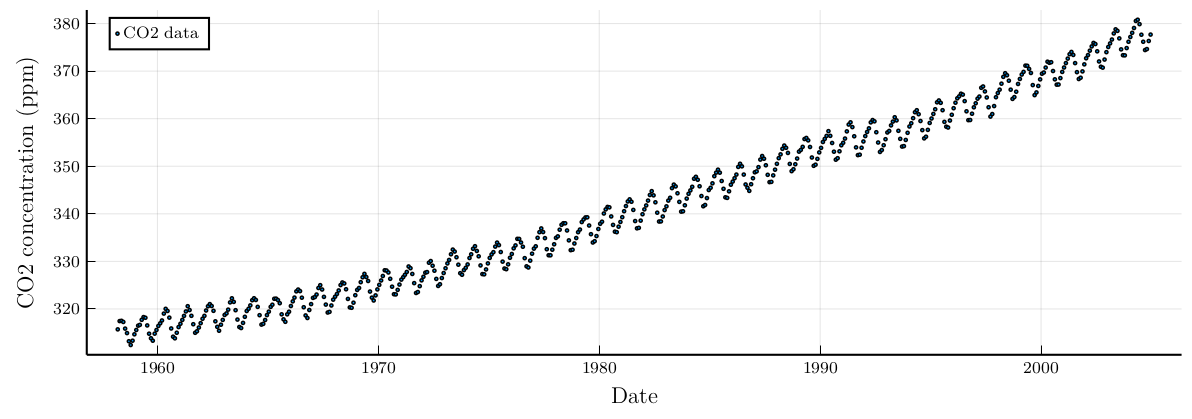

In [5]:
scatter(xtrain, ytrain, size=(800,300), markersize = 1,label="CO2 data",legend=:topleft)
xlabel!("Date")
ylabel!("CO2 concentration (ppm)")

In [229]:
savefig("../texfiles/co2_data.svg")

"/Users/nguyenhuuminhhoang/PhD/GaussianProcessNode/texfiles/co2_data.svg"

In [6]:
Random.seed!(1)
function kernel_gp(θ)
    k1 = softplus(θ[1])*with_lengthscale(SEKernel(), softplus(θ[2])) #long
    k2 = with_lengthscale(PeriodicKernel(), softplus(θ[3])) #period
    k3 = softplus(θ[4])*with_lengthscale(SEKernel(),softplus(θ[5]))
    k4 = softplus(θ[6])*with_lengthscale(RationalQuadraticKernel(α=softplus(θ[7])),softplus(θ[8]))
    k5 = softplus(θ[9])*with_lengthscale(SEKernel(),softplus(θ[10])) #short 
    return  k1 + k2 * k3  + k4 + k5
end
M = 250; #number of inducing points 

Xu = collect(range(1958,2005;length=M));

gpcache = GPCache();
θ_init = invsoftplus.([1., 1., 1.4, 2.4, 1.,1.,0.01,1., 1.16, 1.11]);

w_val = 50
Ψ0 = [1.0;;]
Ψ1_trans = kernelmatrix(kernel_gp(θ_init),Xu,[xtrain[1]])
Ψ2 = kernelmatrix(kernel_gp(θ_init),Xu,[xtrain[1]]) * kernelmatrix(kernel_gp(θ_init),[xtrain[1]],Xu);
Kuu = kernelmatrix(kernel_gp(θ_init), Xu) + 1e-8 * I
Uv = cholesky(Kuu).U;

In [7]:
@model function CO2_MonaLoa(y, x, θ)
    v ~ MvNormalMeanCovariance(zeros(M), 50diageye(M))
    w ~ GammaShapeRate(1e2,1)
    for i in eachindex(y)
        y[i] ~ UniSGP(x[i],v,w,θ)
    end
end
gp_constraints = @constraints begin
    q(v,w) = q(v)q(w)
end

gp_initialization = @initialization begin
    q(w) = GammaShapeRate(1e2,1)
end

@meta function meta_gp_regression(Xu,Ψ0,Ψ1_trans,Ψ2,KuuL,kernel,Uv)
    UniSGP() -> UniSGPMeta(nothing,Xu,Ψ0,Ψ1_trans,Ψ2,KuuL,kernel,Uv,0, N_data)
end

meta_gp_regression (generic function with 1 method)

In [201]:
function my_free_energy(θ)
    kernelmatrix!(Kuu,kernel_gp(θ), Xu)
    KuuL = fastcholesky!(Kuu).L
    infer_result = infer(
        model = CO2_MonaLoa(θ = θ),
        iterations = 5,
        data = (y = ytrain, x = xtrain,),
        initialization = gp_initialization,
        constraints = gp_constraints,
        returnvars = (v = KeepLast(),w = KeepLast(),),
        meta = meta_gp_regression(Xu,Ψ0,Ψ1_trans,Ψ2,KuuL,kernel_gp,Uv),
        free_energy = true,
    )
    return (infer_result.free_energy[end], infer_result.posteriors[:v], infer_result.posteriors[:w])
end


optimizer = Flux.AdaMax();
#perform inference
function PerformInference(θ; epochs)
    grad = similar(θ)
    FE_value = []
    q_v = []
    q_w = []
    θ_optimal = θ
    @inbounds for epoch=1:epochs
            #step 1: Perform inference for v, w 
            fe, qv,qw = my_free_energy(θ_optimal)
            #step 2: optimize the hyperparameters 
            μ_v, Σ_v = mean_cov(qv)
            Rv = Σ_v + μ_v * μ_v' |> (x) -> fastcholesky!(x).U
            w = mean(qw)
            negllh = (θ) -> neg_log_backwardmess_fast(θ;y_data=ytrain, x_data=xtrain,v = μ_v,Uv=Rv, w=w,kernel=kernel_gp,Xu=Xu)
            grad! = (G, θ) -> grad_llh_new_default!(G, θ ;y_data=ytrain, x_data=xtrain,v = μ_v,Uv=Rv, w=w,kernel=kernel_gp,Xu=Xu)
            res = optimize(negllh, grad!, θ_optimal, LBFGS(), Optim.Options(time_limit=200))

            append!(FE_value,fe)
            push!(q_v, qv)
            push!(q_w,qw)
            θ_optimal = res.minimizer
    end
    return q_v[end], q_w[end], FE_value, θ_optimal
end

@time qv, qw, FE, θ_opt = PerformInference(θ_init; epochs = 7);

1597.254419 seconds (2.74 G allocations: 570.605 GiB, 13.89% gc time, 0.08% compilation time: 53% of which was recompilation)


(MvNormalWeightedMeanPrecision(
xi: [890598.1923803175, 905342.1859539895, 919852.7943192096, 933072.7500656386, 944806.6349959695, 955242.6502583671, 964535.542856271, 972675.1588804051, 979537.1417915795, 985004.4210920196  …  1.0230504430924279e6, 1.0181811618859549e6, 1.0116547827794164e6, 1.0034509709642818e6, 993777.4401914374, 982763.2149296852, 970309.6232704348, 956165.0487865922, 940161.6568183134, 922718.4681551049]
Λ: [3306.3118358996335 3443.3107513273712 … 2681.038417064189 2639.718083248514; 3443.3107513273712 3596.0618339866023 … 2722.5762915490973 2681.2486118141346; … ; 2681.038417064189 2722.5762915490973 … 3843.621760437862 3692.14197036057; 2639.718083248514 2681.2486118141346 … 3692.14197036057 3556.5572932778846]
)
, GammaShapeRate{Float64}(a=381.0, b=86.88496070628015), Any[1277.4098594237294, 1266.7904409149487, 1256.4516572205757, 1252.1326439601253, 1248.2128902677505, 1243.4678597205784, 1234.9376078133064], [1.3814841108161091, 0.6717152575737463, 0.7673501

In [ ]:
# @time qv, qw, FE, θ_opt = PerformInference(θ_init; epochs = 7); #approx 30min

#load optimal hyperparameters
θ_opt = load("../savefiles/params_opt_co2data.jld")["params"]

In [11]:
kernelmatrix!(Kuu,kernel_gp(θ_opt), Xu)
KuuL = fastcholesky!(Kuu).L
infer_result = infer(
    model = CO2_MonaLoa(θ = θ_opt),
    iterations = 10,
    data = (y = ytrain, x = xtrain,),
    initialization = gp_initialization,
    constraints = gp_constraints,
    returnvars = (v = KeepLast(),w = KeepLast(),),
    meta = meta_gp_regression(Xu,Ψ0,Ψ1_trans,Ψ2,KuuL,kernel_gp,Uv),
    free_energy = true,
)

qv = infer_result.posteriors[:v]
qw = infer_result.posteriors[:w]
;

In [12]:
function predict_new(x_test,qv,qw,qθ, meta)
    prediction = @call_rule UniSGP(:out, Marginalisation) (q_in=PointMass(x_test),q_v = qv, q_w = qw,q_θ=qθ, meta=meta)
    return prediction
end


predict_mean =[]
predict_var =[]
Kuu = kernelmatrix(kernel_gp(θ_init), Xu) + 1e-8 * I
KuuL = fastcholesky!(Kuu).L
for i=1:length(y_data)
    prediction = predict_new(X_data[i],qv,qw,PointMass(θ_init),UniSGPMeta(nothing,Xu,Ψ0,Ψ1_trans,Ψ2,KuuL,kernel_gp,Uv,0,N_data))
    append!(predict_mean,mean(prediction))
    append!(predict_var,var(prediction)) 
end


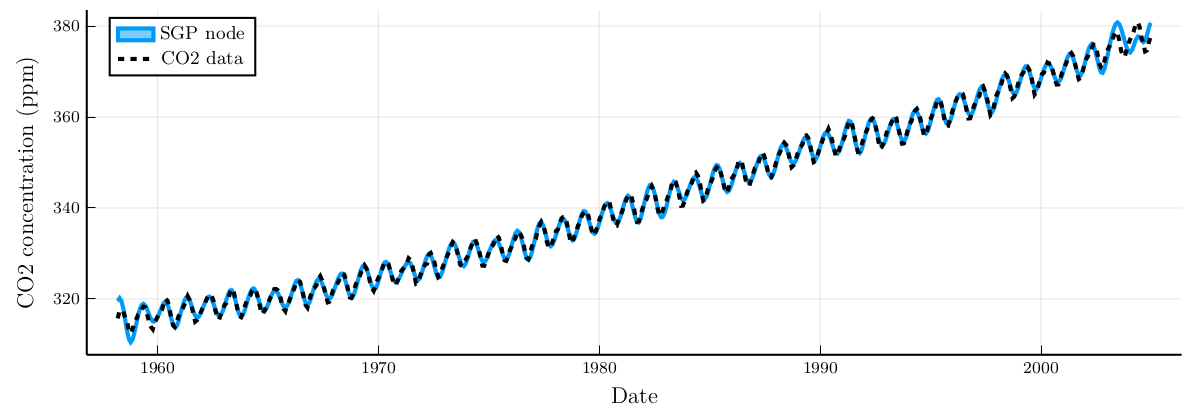

In [13]:
plot(X_data[1:N_data], predict_mean[1:N_data], ribbon = 2 .* sqrt.(predict_var[1:N_data]), 
    size=(800,300),label="SGP node",
    lw = 2,fontfamily="monospace",legendfontsize=9,legend=:topleft)
plot!(X_data[1:N_data], y_data[1:N_data], label="CO2 data",ls = :dash,
    lw = 2, fontfamily="monospace",legendfontsize=9,color=:black)
xlabel!("Date")
ylabel!("CO2 concentration (ppm)")
# vline!([xtrain[end]])

In [ ]:
savefig("../texfiles/co2_result.svg")
# save("../savefiles/params_opt_co2data.jld","params",θ_opt)

"/Users/nguyenhuuminhhoang/PhD/GaussianProcessNode/texfiles/co2_result.svg"